## Imports and setup

In [47]:
import os
import json
import sys
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # In Jupyter, __file__ usually doesn't exist
    NOTEBOOK_DIR = os.getcwd()

# If this notebook lives in "notebooks/", repo root is its parent
if os.path.basename(NOTEBOOK_DIR) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
else:
    # Fall back to "one level up" behavior
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add repo root so `from src...` imports work
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Run-specific results directory
RESULTS_ROOT = os.path.join(REPO_ROOT, "results")
RUN_ID = datetime.now().strftime("%Y-%m-%d_%H.%M.%S")
RUN_DIR = os.path.join(RESULTS_ROOT, "runs", RUN_ID)
FIG_DIR = os.path.join(RUN_DIR, "figures")

os.makedirs(FIG_DIR, exist_ok=True)
print("Saving this run to:", RUN_DIR)

from src.model3d import Small3DCNN
from src.train_utils import TrainConfig, set_seed, train_one_epoch, evaluate, evaluate_loss, save_json, save_checkpoint
from src.dataset_utils import IQOTHNCCDDataset, LungCancerDataset
from torch.utils.data import ConcatDataset

# ----------- Saving locations -----------

# Saving location for metrics 
metrics_path = os.path.join(RUN_DIR, "metrics.json")

# Saving location for plots 
train_loss_path = os.path.join(FIG_DIR, f"train_loss_{RUN_ID}.png")
confusion_matrix_path = os.path.join(FIG_DIR, f"confusion_matrix_{RUN_ID}.png")
table_path = os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png")


Saving this run to: /Users/toriav/Desktop/Erem/CMPE 401/lung-nodule-3d/results/runs/2026-04-11_17.49.54


## Config and device

In [48]:
cfg = TrainConfig(
    epochs=50,
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=128,

    # In macOS notebooks, multiprocessing can break with custom collate_fn
    # Keeping num_workers=0 avoids worker spawn/pickling issues
    num_workers=0,

    # Seed is set for more repeatable runs
    seed=42,

    # Default decision threshold for converting probability -> class label
    threshold=0.5,

    # Trial 3: increased patience to let residual blocks converge before LR decays
    scheduler_patience=6
)

# Use GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Set random seeds across libraries to reduce run-to-run variation
set_seed(cfg.seed)

# Save plots and figures into this folder
os.makedirs("results/figures", exist_ok=True)

device: cpu


## Load NoduleMNIST3D

In [49]:
data_flag = "nodulemnist3d"
info = INFO[data_flag]

# Dataset class name is stored as a string in INFO; fetch the class object
DataClass = getattr(medmnist, info["python_class"])

print("Task:", info["task"])
print("Labels:", info["label"])
print("Channels:", info["n_channels"])

# Some MedMNIST versions omit n_classes; fallback to the number of labels
n_classes = info.get("n_classes", len(info["label"]))
print("Num classes:", n_classes)

Task: binary-class
Labels: {'0': 'benign', '1': 'malignant'}
Channels: 1
Num classes: 2


## Dataset Splitting

In [50]:
# MedMNIST downloads automatically to its cache location when download=True
train_ds = DataClass(split="train", download=True)
val_ds   = DataClass(split="val", download=True)
test_ds  = DataClass(split="test", download=True)

# Quick check - dataset sizes should match expected counts
print("sizes:", len(train_ds), len(val_ds), len(test_ds))

sizes: 1158 165 310


## External Datasets

Two additional datasets are loaded alongside NoduleMNIST3D to broaden
scanner and pathology diversity:

| Dataset | Format | Classes |
|---|---|---|
| **IQ-OTH:NCCD** | 2D JPG slices (stratified 80/10/10 split) | Benign · Malignant · Normal |
| **LungcancerDataSet** | 2D JPG/PNG slices (pre-split train/valid/test) | Benign · Malignant · Normal · 3 carcinoma sub-types |

Because the model expects 28×28×28 voxel volumes, each 2-D slice is
resized to 28×28 and **repeated 28 times along the depth axis** to form
a pseudo-3D volume.  Labels are collapsed to binary (0 = benign/normal,
1 = malignant).

In [51]:
# Paths to the two external datasets inside data/
IQOTH_ROOT      = os.path.join(REPO_ROOT, "data", "IQ-OTH:NCCD")
LUNGCANCER_ROOT = os.path.join(REPO_ROOT, "data", "LungcancerDataSet")

iqoth_train = IQOTHNCCDDataset(IQOTH_ROOT, split="train", seed=cfg.seed)
iqoth_val   = IQOTHNCCDDataset(IQOTH_ROOT, split="val",   seed=cfg.seed)
iqoth_test  = IQOTHNCCDDataset(IQOTH_ROOT, split="test",  seed=cfg.seed)

lcd_train = LungCancerDataset(LUNGCANCER_ROOT, split="train")
lcd_val   = LungCancerDataset(LUNGCANCER_ROOT, split="val")
lcd_test  = LungCancerDataset(LUNGCANCER_ROOT, split="test")

print("IQ-OTH:NCCD    train/val/test:", len(iqoth_train), len(iqoth_val), len(iqoth_test))
print("LungcancerDataSet train/val/test:", len(lcd_train), len(lcd_val), len(lcd_test))

IQ-OTH:NCCD    train/val/test: 877 110 110
LungcancerDataSet train/val/test: 1460 142 475


In [52]:
# Combined datasets: NoduleMNIST3D + IQ-OTH:NCCD + LungcancerDataSet
# The NoduleMNIST3D test set is kept separate so evaluation is
# apples-to-apples with previous trials.
combined_train_ds = ConcatDataset([train_ds, iqoth_train, lcd_train])
combined_val_ds   = ConcatDataset([val_ds,   iqoth_val,   lcd_val])
combined_test_ds  = ConcatDataset([test_ds,  iqoth_test,  lcd_test])

print("Combined train:", len(combined_train_ds))
print("Combined val  :", len(combined_val_ds))
print("Combined test :", len(combined_test_ds))
print("NoduleMNIST3D test (apples-to-apples):", len(test_ds))

Combined train: 3495
Combined val  : 417
Combined test : 895
NoduleMNIST3D test (apples-to-apples): 310


Important note: MedMNIST labels are typically shaped (N, 1). We’ll flatten later.

## Handle class imbalance helper
### Using `pos_weight`

In [53]:
def get_label_array(ds):
    # Works with MedMNIST and Pseudo3DDataset: ds[i][1] is shape (1,)
    y = [int(np.array(ds[i][1]).reshape(-1)[0]) for i in range(len(ds))]
    return np.array(y, dtype=int)

# Use the combined training set for class-balance weighting
y_train = get_label_array(combined_train_ds)
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())

print("combined train positives:", n_pos, "  negatives:", n_neg)

# pos_weight = neg/pos is the standard weighting for BCEWithLogitsLoss
pos_weight_value = (n_neg / max(n_pos, 1))
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

print("pos_weight:", pos_weight_value)

combined train positives: 1669   negatives: 1826
pos_weight: 1.0940683043738766


## DataLoader

In [54]:
import torch.nn.functional as F

def collate_fn(batch, train=False):
    """Collate and normalize a batch; apply enhanced 3D augmentation during training."""
    xs, ys = zip(*batch)

    x = torch.tensor(np.stack(xs)).float()
    y = torch.tensor(np.stack(ys)).long()

    # Ensure x is (B, 1, D, H, W)
    if x.ndim == 4:
        x = x.unsqueeze(1)

    # ---- Per-volume standardization ----
    eps = 1e-6
    mean = x.mean(dim=(2, 3, 4), keepdim=True)
    std  = x.std(dim=(2, 3, 4), keepdim=True)
    x = (x - mean) / (std + eps)

    # ---- Enhanced 3D augmentation (train only) ----
    if train:
        # Random flips along each spatial axis
        for dim in [2, 3, 4]:
            if torch.rand(1).item() < 0.5:
                x = torch.flip(x, dims=[dim])

        # Random 90-degree rotation in the axial (H-W) plane
        if torch.rand(1).item() < 0.3:
            k = torch.randint(1, 4, (1,)).item()
            x = torch.rot90(x, k=k, dims=[3, 4])

        # Mild zoom/crop: upsample by 1.0–1.15×, then center-crop back
        if torch.rand(1).item() < 0.3:
            scale = 1.0 + 0.15 * torch.rand(1).item()
            D, H, W = x.shape[2], x.shape[3], x.shape[4]
            new_D = max(int(D * scale), D + 1)
            x_zoom = F.interpolate(
                x, size=(new_D, new_D, new_D),
                mode="trilinear", align_corners=False,
            )
            s = (new_D - D) // 2
            x = x_zoom[:, :, s:s+D, s:s+H, s:s+W]

        # Random intensity jitter (multiplicative scale)
        if torch.rand(1).item() < 0.3:
            scale = 0.9 + 0.2 * torch.rand(1).item()  # 0.9 – 1.1
            x = x * scale

        # Additive Gaussian noise
        if torch.rand(1).item() < 0.3:
            x = x + 0.05 * torch.randn_like(x)

    return x, y


train_loader = DataLoader(
    combined_train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=True),
)

val_loader = DataLoader(
    combined_val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

# NoduleMNIST3D test only — keeps the apples-to-apples comparison with Trials 1 & 2
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

# Full combined test loader (all three datasets) for holistic evaluation
combined_test_loader = DataLoader(
    combined_test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

# Per-dataset test loaders — for dataset-specific evaluation breakdown
iqoth_test_loader = DataLoader(
    ConcatDataset([iqoth_test]),
    batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

lcd_test_loader = DataLoader(
    ConcatDataset([lcd_test]),
    batch_size=cfg.batch_size, shuffle=False,
    num_workers=cfg.num_workers, pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False),
)

print("nodule test batches:", len(test_loader),
      "  iqoth test batches:", len(iqoth_test_loader),
      "  lcd test batches:", len(lcd_test_loader),
      "  combined test batches:", len(combined_test_loader))

nodule test batches: 3   iqoth test batches: 1   lcd test batches: 4   combined test batches: 7


## Data Visualization

x0 shape: (1, 28, 28, 28) y0: [0]


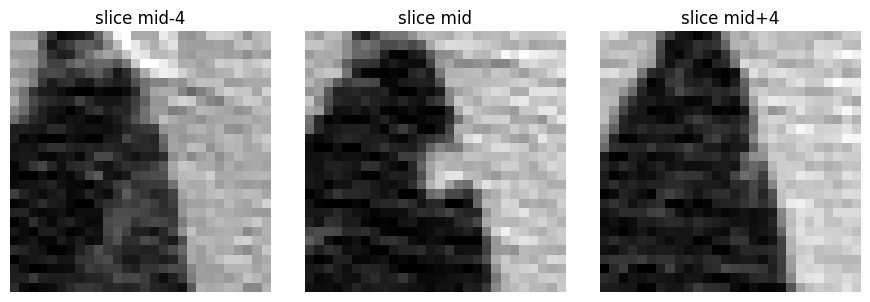

batch shapes: torch.Size([128, 1, 28, 28, 28]) torch.Size([128, 1])


In [55]:
# Inspect a single sample to confirm shapes and label format
x0, y0 = train_ds[0]
x0 = np.array(x0)
print("x0 shape:", x0.shape, "y0:", y0)

# For plotting, drop the channel dimension if present: (1, D, H, W) -> (D, H, W)
vol = x0[0] if x0.ndim == 4 else x0
mid = vol.shape[0] // 2

# Plot a few slices around the center depth
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(vol[mid-4], cmap="gray"); axes[0].set_title("slice mid-4"); axes[0].axis("off")
axes[1].imshow(vol[mid],   cmap="gray"); axes[1].set_title("slice mid");   axes[1].axis("off")
axes[2].imshow(vol[mid+4], cmap="gray"); axes[2].set_title("slice mid+4"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Confirm the DataLoader batch matches the 3D CNN expectation
xb, yb = next(iter(train_loader))
print("batch shapes:", xb.shape, yb.shape)

## Case Examples: Benign vs Malignant

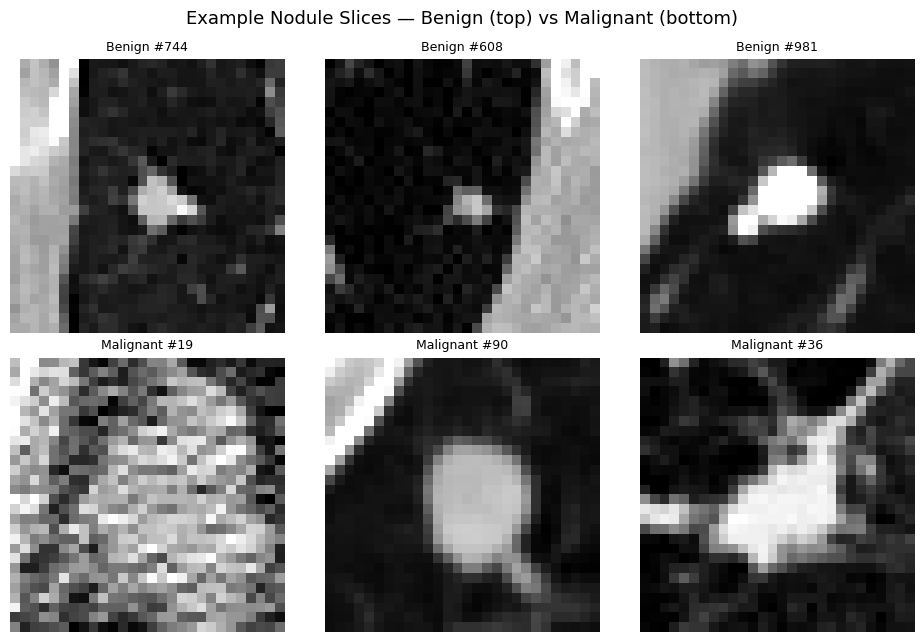

In [56]:
# Representative slices for each class

def show_class_examples(ds, n_per_class=3, seed=0):
    rng = np.random.default_rng(seed)
    y_all = get_label_array(ds)

    benign_idx    = np.where(y_all == 0)[0]
    malignant_idx = np.where(y_all == 1)[0]

    chosen_b = rng.choice(benign_idx,    size=n_per_class, replace=False)
    chosen_m = rng.choice(malignant_idx, size=n_per_class, replace=False)

    fig, axes = plt.subplots(
        2, n_per_class, figsize=(n_per_class * 3.2, 6.5)
    )
    fig.suptitle("Example Nodule Slices — Benign (top) vs Malignant (bottom)", fontsize=13)

    for col, idx in enumerate(chosen_b):
        vol = np.array(ds[idx][0])            # (1, 28, 28, 28) or (28,28,28)
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[0, col].imshow(vol[mid], cmap="gray")
        axes[0, col].set_title(f"Benign #{idx}", fontsize=9)
        axes[0, col].axis("off")

    for col, idx in enumerate(chosen_m):
        vol = np.array(ds[idx][0])
        vol = vol[0] if vol.ndim == 4 else vol
        mid = vol.shape[0] // 2
        axes[1, col].imshow(vol[mid], cmap="gray")
        axes[1, col].set_title(f"Malignant #{idx}", fontsize=9)
        axes[1, col].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"case_examples_{RUN_ID}.png"), dpi=200)
    plt.show()

show_class_examples(train_ds, n_per_class=3)

## Model, Loss, and Optimizer

In [57]:
# Model outputs a single logit for binary classification
model = Small3DCNN(dropout_p=0.3).to(device)

# BCEWithLogitsLoss expects raw logits
# Accounting for class imbalance to improve recall score
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# AdamW is a stable default for this small CNN baseline
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

# Optimizer Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",       # want to maximize AUROC
    factor=0.5,       # reduce LR by half
    patience=cfg.scheduler_patience,  # Trial 3: increased from 3 → 6
    min_lr=1e-6
)

print("num params:", sum(p.numel() for p in model.parameters()))

num params: 883601


## Training loop

In [58]:
# Trial 3: training on combined NoduleMNIST3D + IQ-OTH:NCCD + LungcancerDataSet
# Store training loss and validation metrics per epoch
history = {"train_loss": [], "val_loss": [], "val": []}
best_score = -1.0
best_epoch = -1

for epoch in range(1, cfg.epochs + 1):
    # One full pass over the training set
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Evaluate for validation loss (real BCE loss)
    val_loss = evaluate_loss(model, val_loader, criterion, device)

    # Evaluate on validation set at the current threshold
    # cfg.threshold (0.5) is only used here for epoch-level monitoring during training.
    # Final test evaluation always uses the threshold tuned on the validation set.
    val_metrics = evaluate(model, val_loader, device, threshold=cfg.threshold, criterion=criterion)
    val_metrics["val_loss"] = val_loss

    # Step the scheduler using validation AUROC
    score_for_sched = val_metrics["auroc"] if val_metrics["auroc"] is not None else val_metrics["f1"]
    scheduler.step(score_for_sched)

    print("lr:", optimizer.param_groups[0]["lr"])

    # Log metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val"].append(val_metrics)

    print(
        f"epoch {epoch:02d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
        f"val auroc {val_metrics['auroc']} | val f1 {val_metrics['f1']:.4f}"
    )

    # Saving location for results 
    best_ckpt_path = os.path.join(RUN_DIR, "best.pt")
    # prefer AUROC when available; fallback to F1
    score = val_metrics["auroc"] if val_metrics["auroc"] is not None else val_metrics["f1"]
    if score > best_score:
        best_score = score
        best_epoch = epoch
        save_checkpoint(
            best_ckpt_path,
            model,
            optimizer,
            epoch,
            {"val_metrics": val_metrics, "config": cfg.__dict__},
        )

# Save training history and the best epoch so results are reproducible
save_json(metrics_path, {"history": history, "best_epoch": best_epoch})
print("best_epoch:", best_epoch, "best_score:", best_score)

lr: 0.0003
epoch 01 | train_loss 0.5812 | val_loss 0.6792 | val auroc 0.7436885900991961 | val f1 0.6101


lr: 0.0003
epoch 02 | train_loss 0.4697 | val_loss 0.6981 | val auroc 0.9069390249635653 | val f1 0.4569


lr: 0.0003
epoch 03 | train_loss 0.3867 | val_loss 0.4550 | val auroc 0.9329603685769358 | val f1 0.7431


lr: 0.0003
epoch 04 | train_loss 0.3536 | val_loss 0.3427 | val auroc 0.9263316252174322 | val f1 0.8415


lr: 0.0003
epoch 05 | train_loss 0.3399 | val_loss 0.3548 | val auroc 0.9154482628931409 | val f1 0.8564


...

lr: 7.5e-05
epoch 46 | train_loss 0.1217 | val_loss 0.1730 | val auroc 0.9740021625687555 | val f1 0.9178


lr: 3.75e-05
epoch 47 | train_loss 0.1361 | val_loss 0.1851 | val auroc 0.9717925814489211 | val f1 0.9070


lr: 3.75e-05
epoch 48 | train_loss 0.1186 | val_loss 0.1822 | val auroc 0.9716750505382916 | val f1 0.9153


lr: 3.75e-05
epoch 49 | train_loss 0.1309 | val_loss 0.3175 | val auroc 0.9429975083446946 | val f1 0.8421


lr: 3.75e-05
epoch 50 | train_loss 0.1281 | val_loss 0.1743 | val auroc 0.9745428047576512 | val f1 0.9127
best_epoch: 33 best_score: 0.975765126228198


## Intermediate Feature Map Visualization

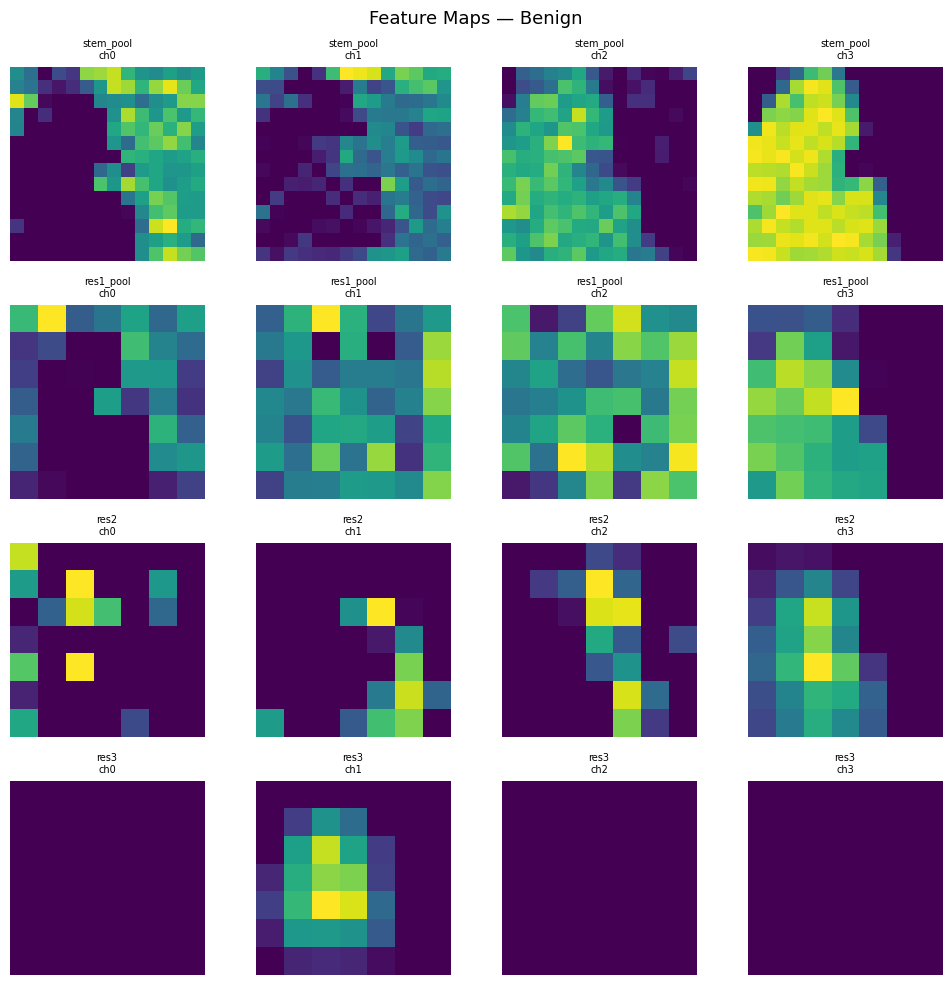

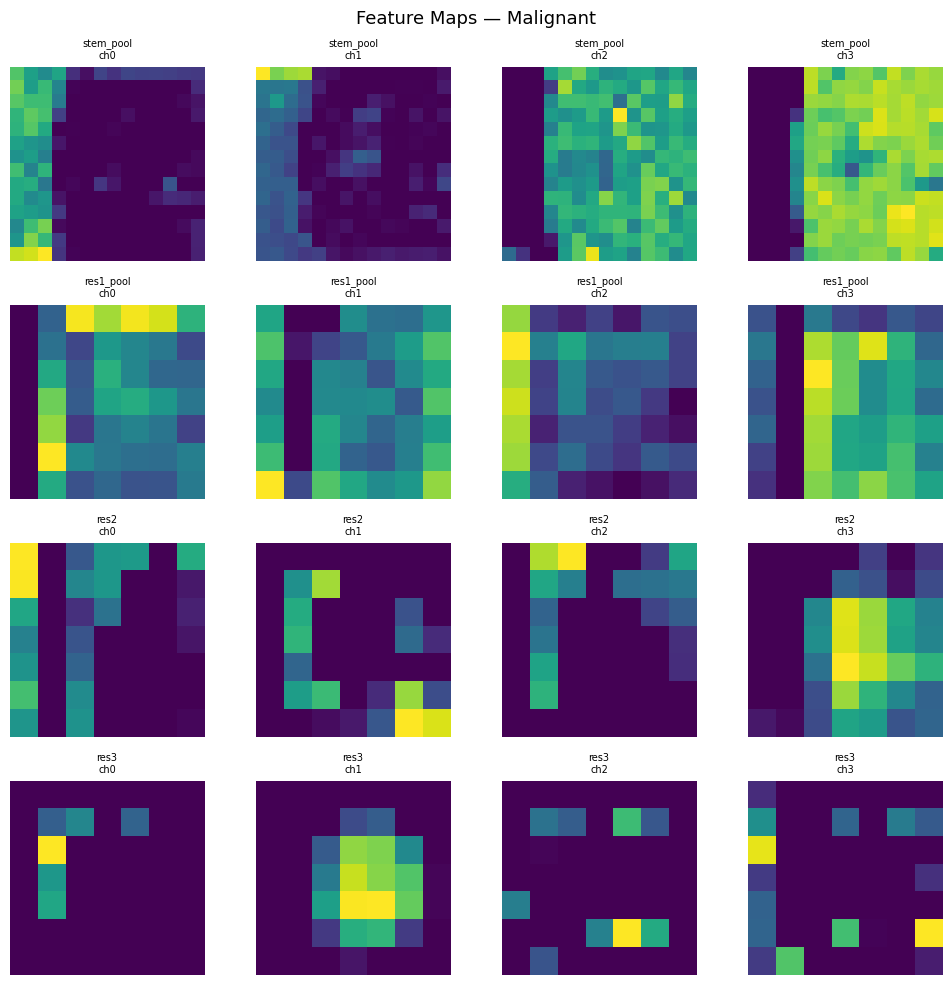

In [59]:
# Pick one benign and one malignant sample, run a forward pass,
# and display the first few channels of each residual stage.

def visualize_feature_maps(model, ds, device, n_channels=4):
    model.eval()
    y_all = get_label_array(ds)

    # pick first benign and first malignant
    idx_b = int(np.where(y_all == 0)[0][0])
    idx_m = int(np.where(y_all == 1)[0][0])

    for label_name, idx in [("Benign", idx_b), ("Malignant", idx_m)]:
        x_raw = np.array(ds[idx][0]).astype(np.float32)
        x_t   = torch.tensor(x_raw).unsqueeze(0)         # (1, 1, 28, 28, 28)
        if x_t.ndim == 4:
            x_t = x_t.unsqueeze(0)

        # Normalise the same way as collate_fn
        eps = 1e-6
        x_t = (x_t - x_t.mean()) / (x_t.std() + eps)
        x_t = x_t.to(device)

        with torch.no_grad():
            maps = model.get_feature_maps(x_t)

        stage_names = list(maps.keys())
        fig, axes = plt.subplots(
            len(stage_names), n_channels,
            figsize=(n_channels * 2.5, len(stage_names) * 2.5)
        )
        fig.suptitle(f"Feature Maps — {label_name}", fontsize=13)

        for row, sname in enumerate(stage_names):
            fmap = maps[sname][0]        # (C, D, H, W) – drop batch dim
            mid_d = fmap.shape[1] // 2  # middle depth slice
            for col in range(n_channels):
                ax = axes[row, col] if len(stage_names) > 1 else axes[col]
                ch_map = fmap[col, mid_d].numpy()
                ax.imshow(ch_map, cmap="viridis")
                ax.set_title(f"{sname}\nch{col}", fontsize=7)
                ax.axis("off")

        plt.tight_layout()
        plt.savefig(
            os.path.join(FIG_DIR, f"feature_maps_{label_name.lower()}_{RUN_ID}.png"),
            dpi=200
        )
        plt.show()

visualize_feature_maps(model, train_ds, device, n_channels=4)

## Threshold Tuning with Combined Validation Set

Sweep decision thresholds on the combined validation set and pick the one
that maximises F1. This tuned threshold is used for **all** final test evaluations.

In [60]:
@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        all_logits.append(model(x).cpu().numpy())
        all_y.append(y.numpy().reshape(-1))
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

y_val, logits_val = get_logits_and_labels(model, val_loader, device)

from src.metrics import compute_binary_metrics

thresholds = np.linspace(0.05, 0.95, 19)
best = None
sweep_rows = []

for t in thresholds:
    met = compute_binary_metrics(y_val, logits_val, threshold=float(t))
    row = {"threshold": float(t), **{k: met[k] for k in
           ["f1","recall","precision","specificity","accuracy","auroc"]}}
    sweep_rows.append(row)
    if best is None or row["f1"] > best["f1"]:
        best = row

best_threshold = best["threshold"]
print(f"Best threshold by F1: {best_threshold:.2f}  "
      f"(F1={best['f1']:.3f}, Recall={best['recall']:.3f}, "
      f"Precision={best['precision']:.3f})")

Best threshold by F1: 0.60  (F1=0.917, Recall=0.899, Precision=0.936)


## Training Curves

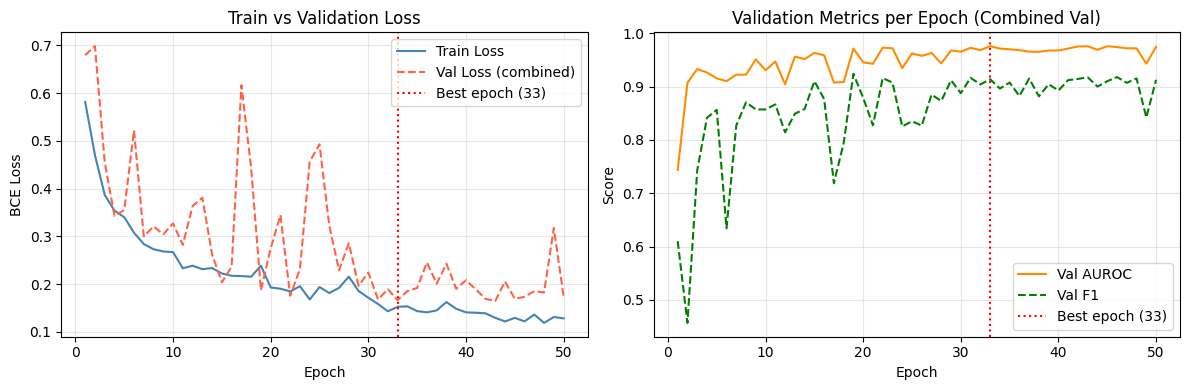

In [61]:
train_losses = history["train_loss"]
val_losses   = history["val_loss"]
val_aurocs   = [v["auroc"] for v in history["val"]]
val_f1s      = [v["f1"]    for v in history["val"]]

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_losses, label="Train Loss", color="steelblue")
axes[0].plot(epochs_range, val_losses,   label="Val Loss (combined)", color="tomato", linestyle="--")
axes[0].axvline(best_epoch, color="red", linestyle=":", label=f"Best epoch ({best_epoch})")
axes[0].set_title("Train vs Validation Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, val_aurocs, label="Val AUROC", color="darkorange")
axes[1].plot(epochs_range, val_f1s,   label="Val F1",    color="green", linestyle="--")
axes[1].axvline(best_epoch, color="red", linestyle=":", label=f"Best epoch ({best_epoch})")
axes[1].set_title("Validation Metrics per Epoch (Combined Val)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"train_val_curves_{RUN_ID}.png"), dpi=200)
plt.show()

## Test Evaluation

Each dataset is evaluated with the threshold tuned on the combined validation set.
NoduleMNIST3D is kept as the primary apples-to-apples benchmark across trials.

In [62]:
nodule_test_tuned   = evaluate(model, test_loader,          device, threshold=best_threshold)
iqoth_test_tuned    = evaluate(model, iqoth_test_loader,     device, threshold=best_threshold)
lcd_test_tuned      = evaluate(model, lcd_test_loader,       device, threshold=best_threshold)
combined_test_tuned = evaluate(model, combined_test_loader,  device, threshold=best_threshold)

print(f"Tuned threshold = {best_threshold:.2f}\n")
for name, m in [
    ("NoduleMNIST3D",     nodule_test_tuned),
    ("IQ-OTH:NCCD",       iqoth_test_tuned),
    ("LungcancerDataSet", lcd_test_tuned),
    ("Combined",          combined_test_tuned),
]:
    print(f"{name:20s}  AUROC={m['auroc']:.3f}  F1={m['f1']:.3f}  "
          f"Recall={m['recall']:.3f}  Precision={m['precision']:.3f}  "
          f"Spec={m['specificity']:.3f}")

# Persist
with open(metrics_path, "r") as f:
    m_all = json.load(f)
m_all["best_threshold_val_f1"]         = best
m_all["test_nodule_threshold"]         = nodule_test_tuned
m_all["test_iqoth_threshold"]         = iqoth_test_tuned
m_all["test_lcd_threshold"]           = lcd_test_tuned
m_all["test_combined_threshold"]      = combined_test_tuned
with open(metrics_path, "w") as f:
    json.dump(m_all, f, indent=2)
# Alias so the results table below can reference it
test_metrics_tuned = nodule_test_tuned

Tuned threshold = 0.60

NoduleMNIST3D         AUROC=0.922  F1=0.678  Recall=0.641  Precision=0.719  Spec=0.935
IQ-OTH:NCCD           AUROC=0.999  F1=0.982  Recall=1.000  Precision=0.966  Spec=0.963
LungcancerDataSet     AUROC=0.990  F1=0.938  Recall=0.894  Precision=0.987  Spec=0.970
Combined              AUROC=0.974  F1=0.908  Recall=0.872  Precision=0.948  Spec=0.949


## Confusion Matrices

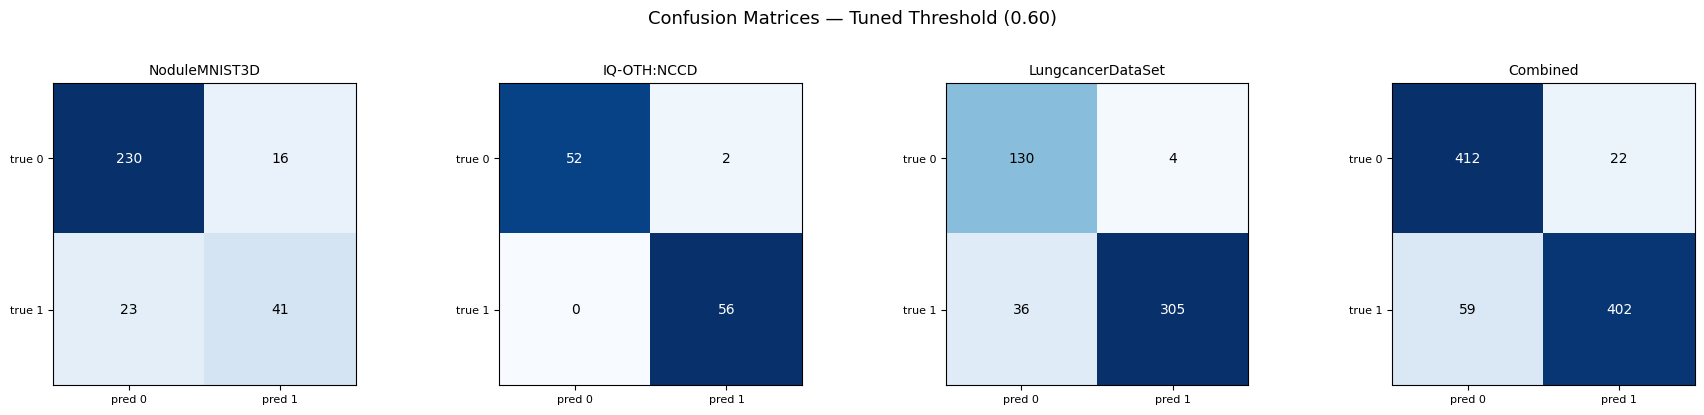

In [63]:
dataset_results_tuned = [
    ("NoduleMNIST3D",     nodule_test_tuned),
    ("IQ-OTH:NCCD",       iqoth_test_tuned),
    ("LungcancerDataSet", lcd_test_tuned),
    ("Combined",          combined_test_tuned),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f"Confusion Matrices — Tuned Threshold ({best_threshold:.2f})", fontsize=13, y=1.02)

for ax, (name, met) in zip(axes, dataset_results_tuned):
    cm = np.array(met["confusion_matrix"])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.set_title(name, fontsize=10)
    ax.set_xticks([0,1]); ax.set_xticklabels(["pred 0","pred 1"], fontsize=8)
    ax.set_yticks([0,1]); ax.set_yticklabels(["true 0","true 1"], fontsize=8)
    thresh_cm = cm.max() * 0.6
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center",
                    color="white" if cm[i,j] > thresh_cm else "black", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"confusion_matrices_tuned_{RUN_ID}.png"), dpi=200)
plt.show()

## Logistic Regression Baseline
### Flattened voxels, NoduleMNIST3D only

In [64]:
def flatten_dataset(ds):
    X, y = [], []
    for i in range(len(ds)):
        x_i, y_i = ds[i]
        X.append(np.array(x_i).astype(np.float32).reshape(-1))
        y.append(int(np.array(y_i).reshape(-1)[0]))
    return np.stack(X), np.array(y)

X_train_lr, y_train_lr = flatten_dataset(train_ds)
X_val_lr,   y_val_lr   = flatten_dataset(val_ds)
X_test_lr,  y_test_lr  = flatten_dataset(test_ds)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)
clf.fit(X_train_lr, y_train_lr)

lr_metrics = compute_binary_metrics(
    y_test_lr, clf.decision_function(X_test_lr), threshold=0.5
)
print(lr_metrics)

with open(metrics_path, "r") as f:
    m_all = json.load(f)
m_all["logreg_baseline_test"] = lr_metrics
with open(metrics_path, "w") as f:
    json.dump(m_all, f, indent=2)

{'auroc': 0.8226626016260162, 'f1': 0.5384615384615384, 'accuracy': 0.8064516129032258, 'precision': 0.5303030303030303, 'recall': 0.546875, 'specificity': 0.8739837398373984, 'confusion_matrix': [[215, 31], [29, 35]]}


## Results Summary Table

3D CNN evaluated at the tuned threshold across all datasets, compared against
the NoduleMNIST3D logistic regression baseline.

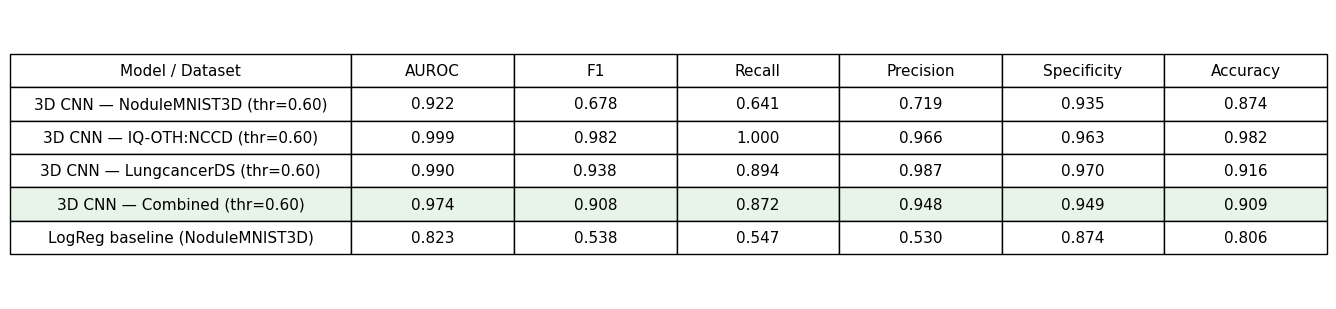

In [65]:
def fmt(v):
    return "N/A" if v is None else f"{v:.3f}"

def row_from_metrics(name, met):
    return [name,
            fmt(met.get("auroc")),
            fmt(met.get("f1")),
            fmt(met.get("recall")),
            fmt(met.get("precision")),
            fmt(met.get("specificity")),
            fmt(met.get("accuracy"))]

thr_label = f"thr={best_threshold:.2f}"
rows_table = [
    row_from_metrics(f"3D CNN — NoduleMNIST3D ({thr_label})",   nodule_test_tuned),
    row_from_metrics(f"3D CNN — IQ-OTH:NCCD ({thr_label})",     iqoth_test_tuned),
    row_from_metrics(f"3D CNN — LungcancerDS ({thr_label})",     lcd_test_tuned),
    row_from_metrics(f"3D CNN — Combined ({thr_label})",         combined_test_tuned),
    row_from_metrics("LogReg baseline (NoduleMNIST3D)",          lr_metrics),
]

col_labels = ["Model / Dataset", "AUROC", "F1", "Recall", "Precision", "Specificity", "Accuracy"]

fig, ax = plt.subplots(figsize=(14, 3.2))
ax.axis("off")
table = ax.table(
    cellText=rows_table,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.7)
for (r, c), cell in table.get_celld().items():
    if c == 0:
        cell.set_width(cell.get_width() * 2.1)
    # highlight the combined row
    if r == 4:
        cell.set_facecolor("#e8f4e8")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png"), dpi=300)
plt.show()